In [3]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = r"E:\Masters Data Analytics\MSDA-class-work\DATA-230\Final project\OCT_2025_RBS_FULL_DATA_SET.XLSX"

df = pd.read_excel(file_path)

print(df.head())
print(df.info())
print(df.describe())

df.to_csv("dataset.csv", index=False)

                  ROUTE_NAME  ROUTE_NUMBER SERVICE_PERIOD SERVICE_CODE  \
0  22: Palo Alto - Eastridge          22.0       Saturday     Frequent   
1  22: Palo Alto - Eastridge          22.0       Saturday     Frequent   
2  22: Palo Alto - Eastridge          22.0       Saturday     Frequent   
3  22: Palo Alto - Eastridge          22.0       Saturday     Frequent   
4  22: Palo Alto - Eastridge          22.0       Saturday     Frequent   

  DIRECTION_NAME                     BRANCH TRIP_TIME  SORT_ORDER  STOP_ID  \
0           EAST  [22]Palo Alto > Eastridge  00:35:00       680.0      1.0   
1           EAST  [22]Palo Alto > Eastridge  01:57:00       680.0      1.0   
2           EAST  [22]Palo Alto > Eastridge  04:32:00       680.0      1.0   
3           EAST  [22]Palo Alto > Eastridge  04:58:00       680.0      1.0   
4           EAST  [22]Palo Alto > Eastridge  05:23:00       680.0      1.0   

            MAIN_CROSS_STREET  ...  Stop_ID_Num  STOP_DISPLAY  \
0  SANTA CLARA TRANSI

In [4]:
import matplotlib
print(matplotlib.__version__)

3.10.8


Original shape: (388202, 32)
Cleaned shape: (382720, 32)
Cleaned CSV saved to: E:\Masters Data Analytics\MSDA-class-work\DATA-230\Final project\cleaned_dataset.csv

First 5 rows:
                  route_name  route_number service_period service_code  \
0  22: Palo Alto - Eastridge          22.0       Saturday     Frequent   
1  22: Palo Alto - Eastridge          22.0       Saturday     Frequent   
2  22: Palo Alto - Eastridge          22.0       Saturday     Frequent   
3  22: Palo Alto - Eastridge          22.0       Saturday     Frequent   
4  22: Palo Alto - Eastridge          22.0       Saturday     Frequent   

  direction_name                     branch trip_time  sort_order  stop_id  \
0           EAST  [22]Palo Alto > Eastridge  00:35:00       680.0      1.0   
1           EAST  [22]Palo Alto > Eastridge  01:57:00       680.0      1.0   
2           EAST  [22]Palo Alto > Eastridge  04:32:00       680.0      1.0   
3           EAST  [22]Palo Alto > Eastridge  04:58:00       680.

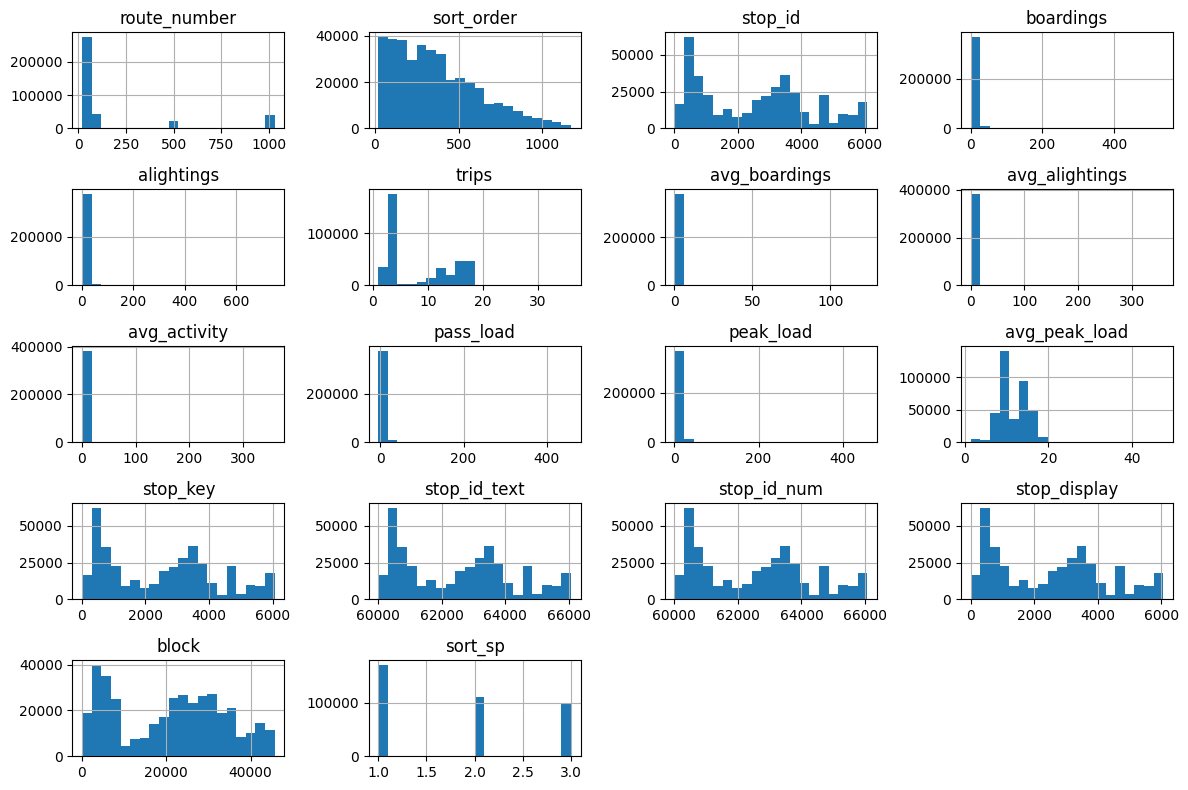

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype

# -----------------------------
# 1. Load Excel file
# -----------------------------
file_path = r"E:\Masters Data Analytics\MSDA-class-work\DATA-230\Final project\OCT_2025_RBS_FULL_DATA_SET.XLSX"
df = pd.read_excel(file_path)

print("Original shape:", df.shape)

# -----------------------------
# 2. Data Preparation / Cleaning
# -----------------------------

# Remove duplicate rows
df = df.drop_duplicates()

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Remove completely empty rows and columns
df = df.dropna(how="all")
df = df.dropna(axis=1, how="all")

# Replace common missing-value strings with actual NaN
df = df.replace(["", " ", "NA", "N/A", "null", "None"], pd.NA)

# Strip whitespace from text columns
for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].astype(str).str.strip()

# Try converting text columns to numeric only when it makes sense
for col in df.columns:
    if not is_numeric_dtype(df[col]):
        converted = pd.to_numeric(df[col], errors="coerce")
        # convert only if most non-null values were numeric-like
        original_non_null = df[col].notna().sum()
        converted_non_null = converted.notna().sum()

        if original_non_null > 0 and (converted_non_null / original_non_null) >= 0.8:
            df[col] = converted

# Fill missing values
for col in df.columns:
    if is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna("Unknown")

print("Cleaned shape:", df.shape)

# -----------------------------
# 3. Save cleaned data to CSV
# -----------------------------
output_csv = r"E:\Masters Data Analytics\MSDA-class-work\DATA-230\Final project\cleaned_dataset.csv"
df.to_csv(output_csv, index=False)
print(f"Cleaned CSV saved to: {output_csv}")

# -----------------------------
# 4. EDA
# -----------------------------
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nSummary statistics:")
print(df.describe(include="all"))

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

print("\nTop values for categorical columns:")
for col in df.select_dtypes(exclude="number").columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts().head(5))

# -----------------------------
# 5. Histograms for numeric columns
# -----------------------------
numeric_df = df.select_dtypes(include="number")

if not numeric_df.empty:
    numeric_df.hist(figsize=(12, 8), bins=20)
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns available for histograms.")

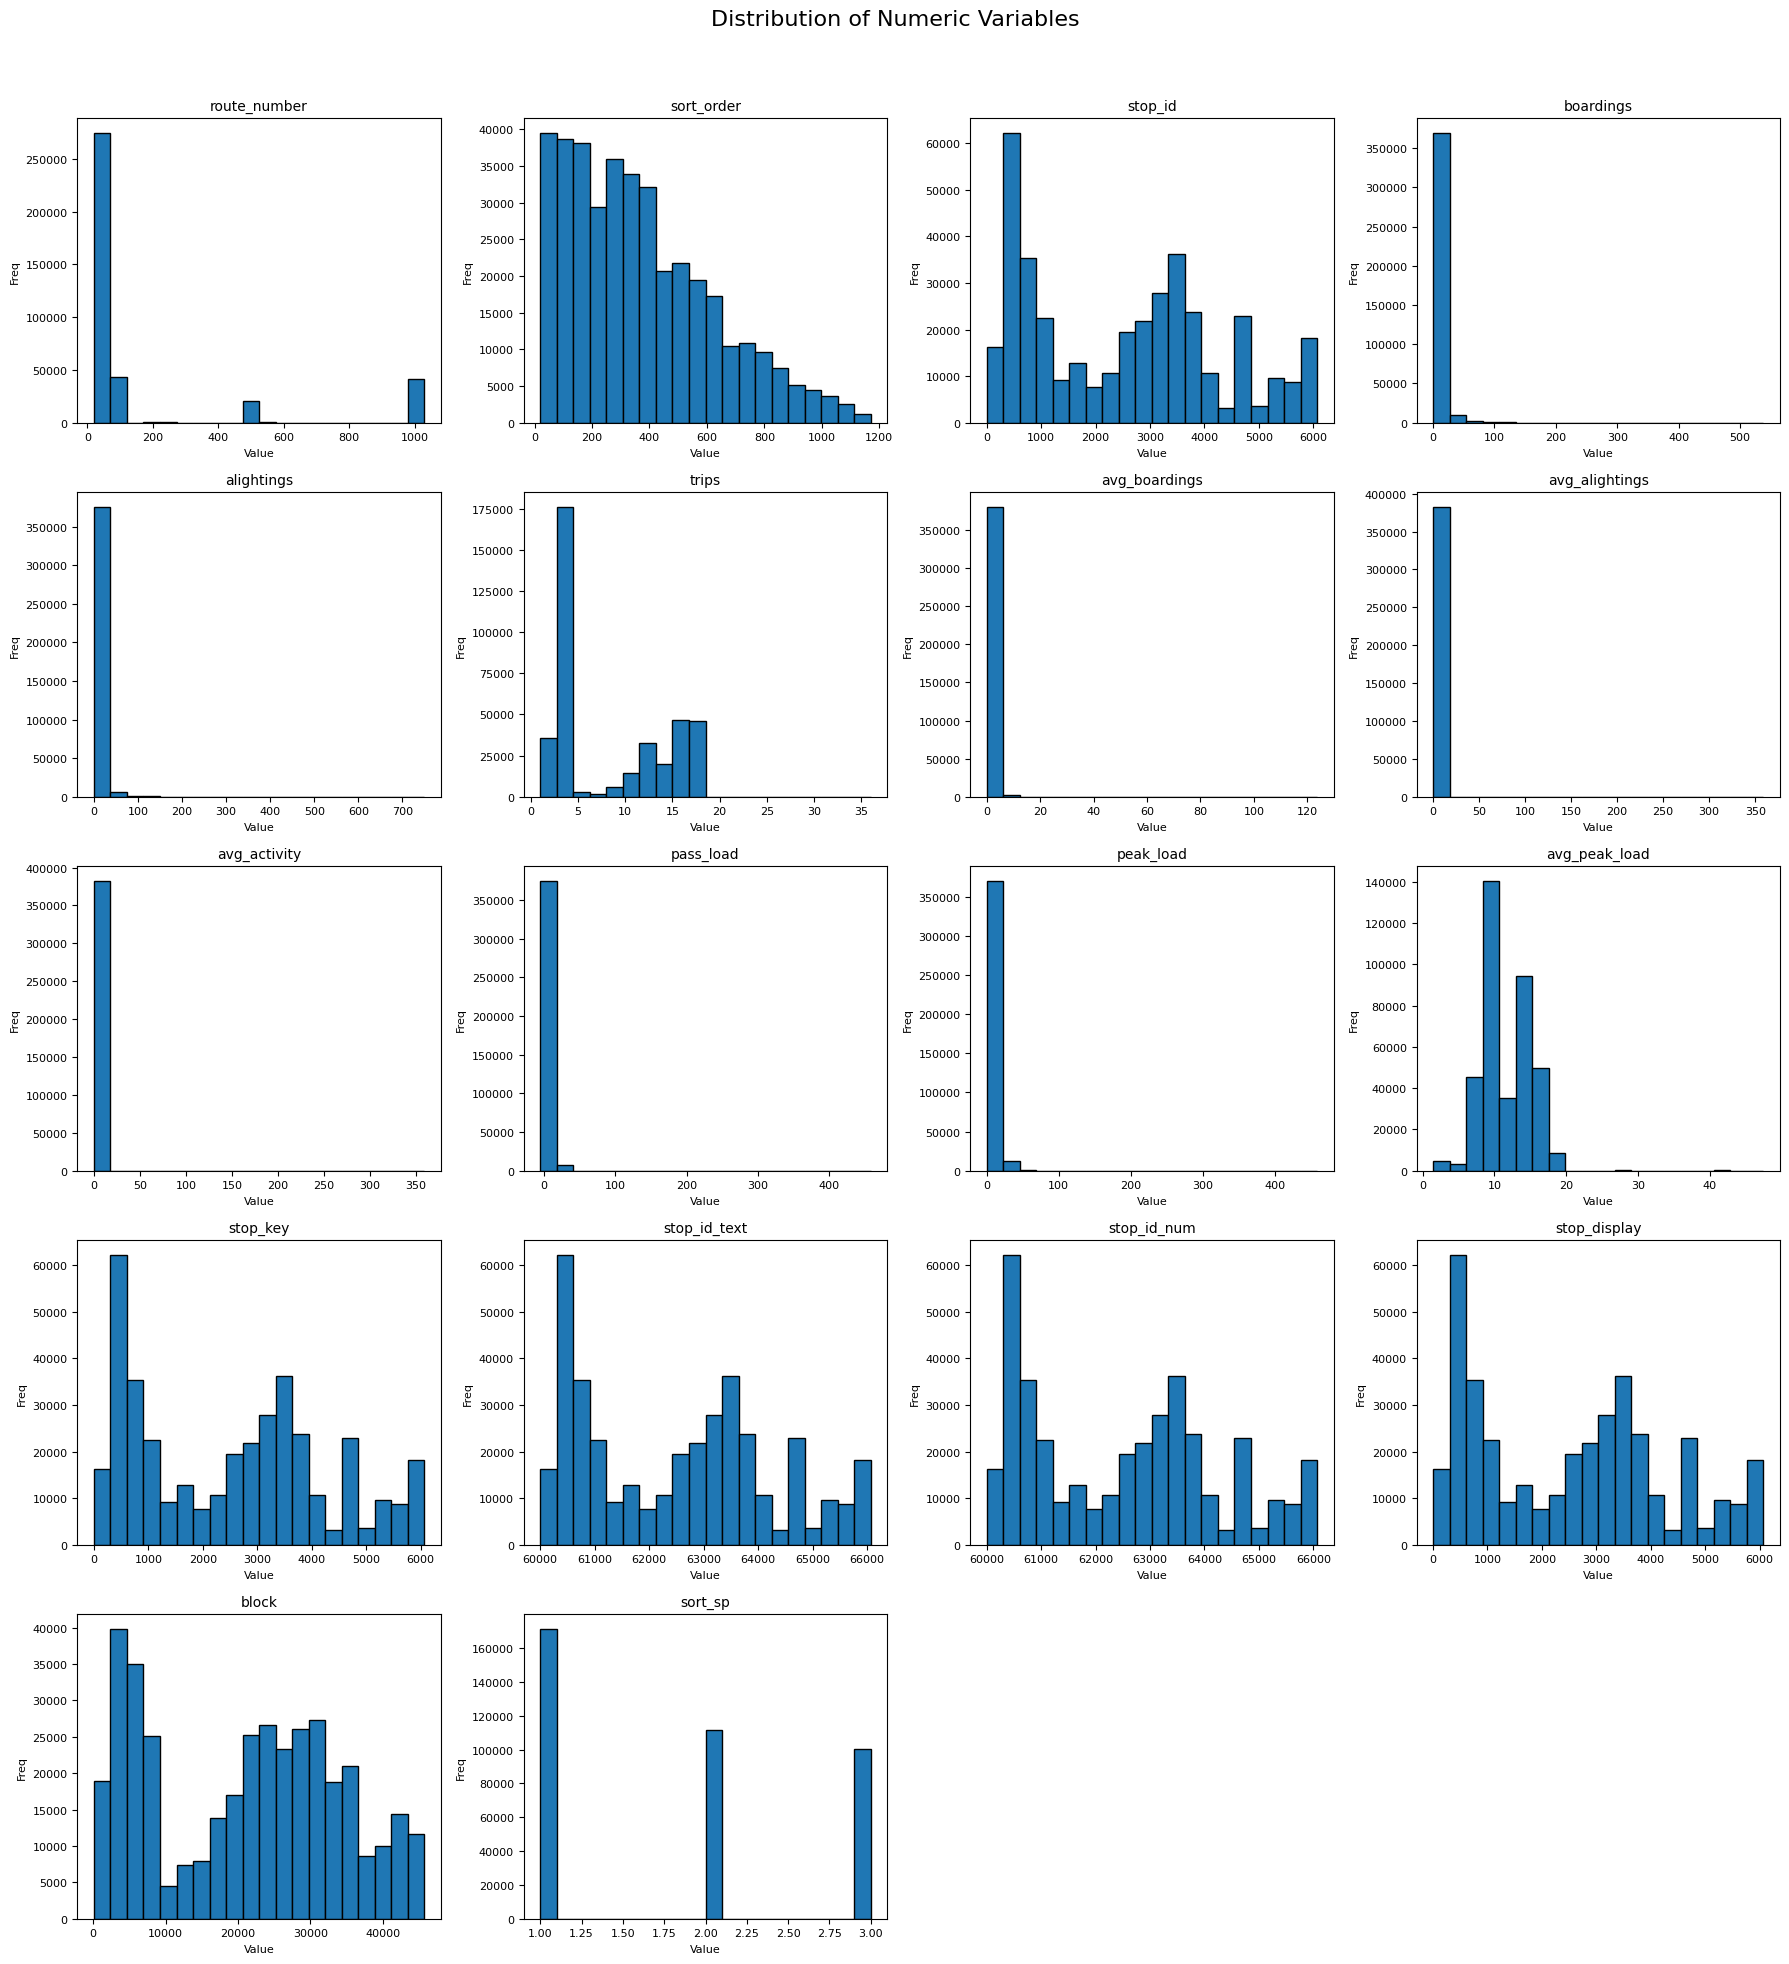

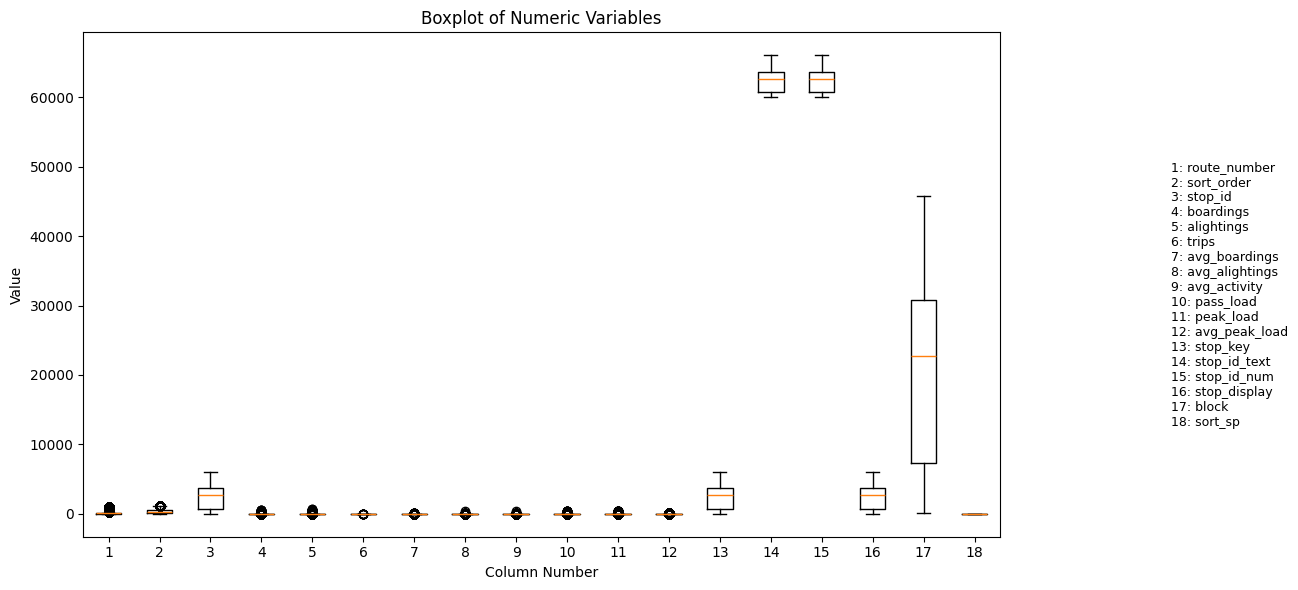

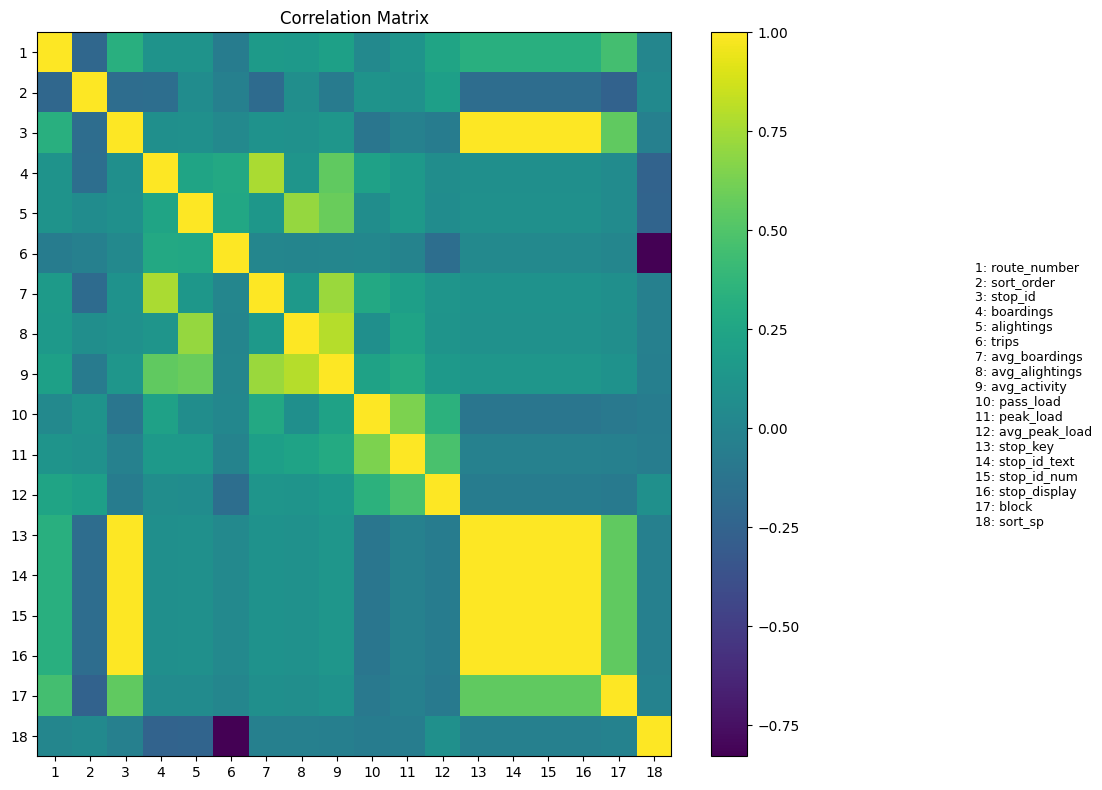

Columns: Index(['route_name', 'route_number', 'service_period', 'service_code',
       'direction_name', 'branch', 'trip_time', 'sort_order', 'stop_id',
       'main_cross_street', 'boardings', 'alightings', 'trips',
       'avg_boardings', 'avg_alightings', 'avg_activity', 'pass_load',
       'peak_load', 'avg_peak_load', 'city', 'stop_key', 'stop_id_text',
       'stop_id_num', 'stop_display', 'additional_notes', 'pattern_key',
       'block', 'total_sort', 'sort_sp', 'route_rev', 'service_code2',
       'stop_id_rev'],
      dtype='str')
Using rider column: boardings
Grouped data:
route_name
101: Camden & Hwy 85 - Stanford Research Park     363.0
102: South San Jose - Stanford Research Park     1036.0
103: Eastridge - Stanford Research Park           518.0
104: Milpitas BART - Stanford Research Park       393.0
121: Gilroy Trans Ctr - Lockheed Martin           726.0
Name: boardings, dtype: float64


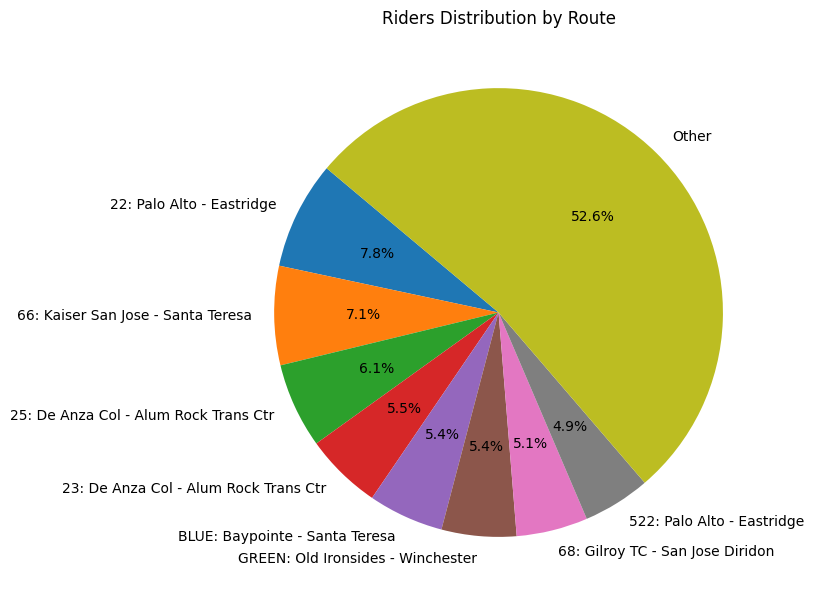

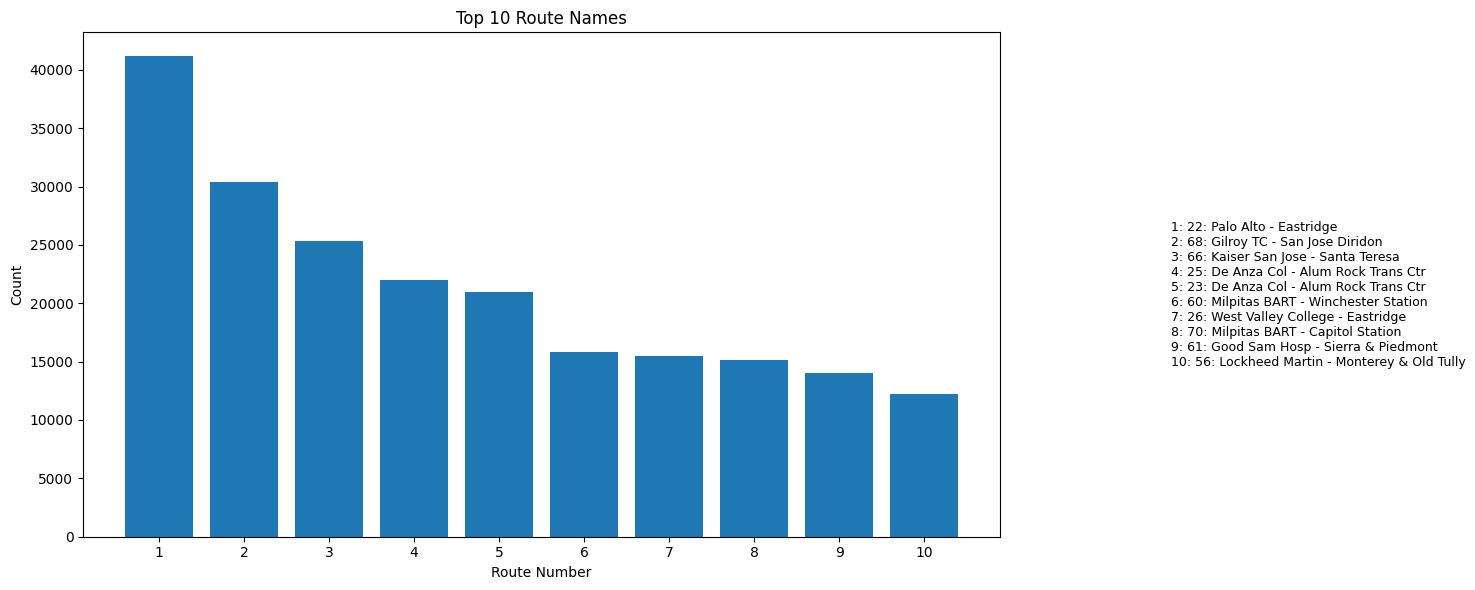

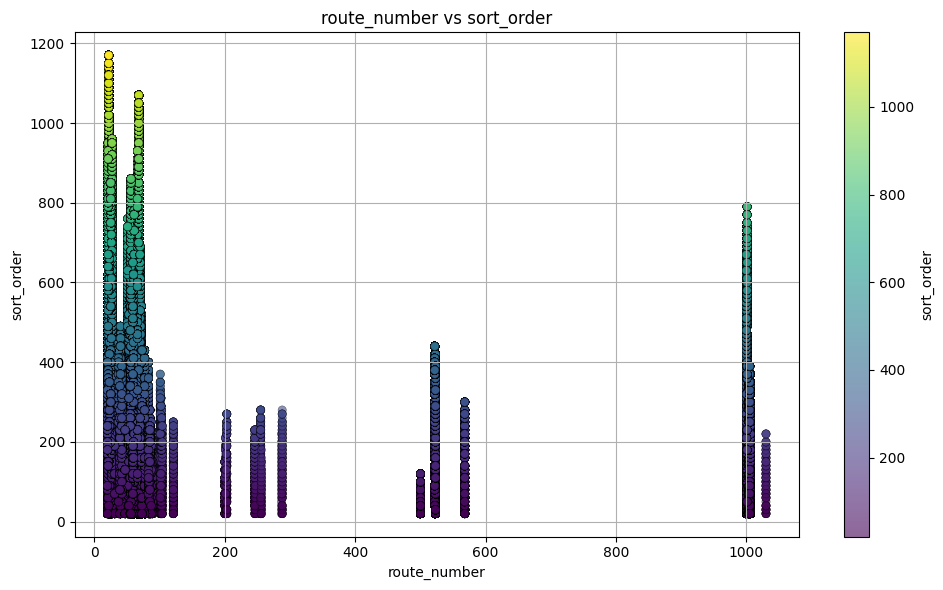

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------
# Prepare column groups
# -----------------------------------
numeric_df = df.select_dtypes(include="number")
categorical_df = df.select_dtypes(exclude="number")

numeric_cols = numeric_df.columns.tolist()
num_map = {i + 1: col for i, col in enumerate(numeric_cols)}

def add_key_to_plot(mapping, x_pos=0.98, y_pos=0.5, fontsize=9):
    """Adds numbered key to right side of current figure"""
    key_text = "\n".join([f"{i}: {name}" for i, name in mapping.items()])
    plt.gcf().text(x_pos, y_pos, key_text, fontsize=fontsize, va="center", ha="left")

# -----------------------------------
# 1. Histogram
# -----------------------------------
if not numeric_df.empty:
    n = len(numeric_cols)
    cols = 4
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))

    # Make axes always iterable
    if n == 1:
        axes = [axes]
    else:
        axes = np.array(axes).flatten()

    for i, col in enumerate(numeric_cols):
        axes[i].hist(
            numeric_df[col].dropna(),
            bins=20,
            edgecolor="black"
        )
        axes[i].set_title(col, fontsize=10)
        axes[i].set_xlabel("Value", fontsize=8)
        axes[i].set_ylabel("Freq", fontsize=8)
        axes[i].tick_params(axis="both", labelsize=8)

    # Hide unused subplots
    for j in range(len(numeric_cols), len(axes)):
        axes[j].axis("off")

    fig.suptitle("Distribution of Numeric Variables", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
else:
    print("No numeric columns available for histogram.")

# -----------------------------------
# 2. Boxplot
# -----------------------------------
if not numeric_df.empty:
    plt.figure(figsize=(12, 6))

    # Use list of each numeric column individually
    boxplot_data = [numeric_df[col].dropna() for col in numeric_cols]

    plt.boxplot(boxplot_data)
    plt.xticks(range(1, len(numeric_cols) + 1), range(1, len(numeric_cols) + 1))
    plt.title("Boxplot of Numeric Variables")
    plt.xlabel("Column Number")
    plt.ylabel("Value")

    add_key_to_plot(num_map)

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()
else:
    print("No numeric columns available for boxplot.")

# -----------------------------------
# 3. Correlation Heatmap
# -----------------------------------
if numeric_df.shape[1] >= 2:
    corr = numeric_df.corr()

    plt.figure(figsize=(10, 8))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()

    plt.xticks(range(len(corr.columns)), range(1, len(corr.columns) + 1))
    plt.yticks(range(len(corr.columns)), range(1, len(corr.columns) + 1))
    plt.title("Correlation Matrix")

    add_key_to_plot(num_map)

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()
else:
    print("Not enough numeric columns for correlation heatmap.")

import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------------
# 4. Pie Chart: Riders per Route (FIXED)
# -----------------------------------

# Step 1: Check columns
print("Columns:", df.columns)

# Try to find rider column automatically
possible_cols = ["riders", "ridership", "boardings", "passengers"]

rider_col = None
for col in possible_cols:
    if col in df.columns:
        rider_col = col
        break

if rider_col is None:
    print("No rider column found. Check your column names.")
else:
    print("Using rider column:", rider_col)

    # Step 2: Clean numeric data
    df[rider_col] = pd.to_numeric(df[rider_col], errors="coerce")

    # Step 3: Drop missing
    clean_df = df[["route_name", rider_col]].dropna()

    # Step 4: Group data
    route_riders = clean_df.groupby("route_name")[rider_col].sum()

    # Remove zero values
    route_riders = route_riders[route_riders > 0]

    print("Grouped data:")
    print(route_riders.head())

    if route_riders.empty:
        print("No valid data to plot.")
    else:
        # Step 5: Limit to top routes
        route_riders = route_riders.sort_values(ascending=False)

        top_n = 8
        top_routes = route_riders.head(top_n)

        other = route_riders.iloc[top_n:].sum()
        if other > 0:
            top_routes["Other"] = other

        # Step 6: Plot
        plt.figure(figsize=(8,8))

        plt.pie(
            top_routes.values,
            labels=top_routes.index,
            autopct="%1.1f%%",
            startangle=140
        )

        plt.title("Riders Distribution by Route")
        plt.tight_layout()
        plt.show()

# -----------------------------------
# 5. Top Category Distribution
# -----------------------------------
if "route_name" in df.columns:
    top_routes = df["route_name"].astype(str).value_counts().head(10)

    if not top_routes.empty:
        route_names = top_routes.index.tolist()
        route_counts = top_routes.values
        route_map = {i + 1: name for i, name in enumerate(route_names)}

        plt.figure(figsize=(12, 6))
        plt.bar(range(1, len(route_counts) + 1), route_counts)

        plt.xlabel("Route Number")
        plt.ylabel("Count")
        plt.title("Top 10 Route Names")
        plt.xticks(range(1, len(route_counts) + 1))

        add_key_to_plot(route_map)

        plt.tight_layout(rect=[0, 0, 0.85, 1])
        plt.show()
    else:
        print("No route_name values available to plot.")
else:
    print("Column 'route_name' not found.")

# -----------------------------------
# 6. Clearer Scatter Plot
# -----------------------------------
if len(numeric_cols) >= 2:
    x = numeric_cols[0]
    y = numeric_cols[1]

    scatter_df = df[[x, y]].dropna()

    if not scatter_df.empty:
        plt.figure(figsize=(10, 6))
        plt.scatter(
            scatter_df[x],
            scatter_df[y],
            c=scatter_df[y],
            cmap="viridis",
            alpha=0.6,
            edgecolors="black",
            linewidths=0.3
        )

        plt.colorbar(label=y)
        plt.xlabel(x)
        plt.ylabel(y)
        plt.title(f"{x} vs {y}")
        plt.grid(True)

        plt.tight_layout()
        plt.show()
    else:
        print(f"No valid data to plot for {x} vs {y}.")
else:
    print("Not enough numeric columns for scatter plot.")

In [ ]:
import pandas as pd
import numpy as np

# Load file
file_path = r"E:\Masters Data Analytics\MSDA-class-work\DATA-230\Final project\OCT_2025_RBS_FULL_DATA_SET.XLSX"
df = pd.read_excel(file_path)

# -----------------------------
# 1. Basic cleanup
# -----------------------------
df = df.drop_duplicates()
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df = df.dropna(how="all")
df = df.dropna(axis=1, how="all")

# Standardize missing values
df = df.replace(["", " ", "NA", "N/A", "na", "null", "None", "nan"], np.nan)

# Clean text columns
text_cols = df.select_dtypes(include=["object", "string"]).columns
for col in text_cols:
    df[col] = df[col].astype("string").str.strip()

# -----------------------------
# 2. Try to convert text columns to numeric where appropriate
# -----------------------------
for col in df.columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        converted = pd.to_numeric(df[col], errors="coerce")
        original_non_null = df[col].notna().sum()
        converted_non_null = converted.notna().sum()

        # Convert only if at least 80% of non-null values are numeric-like
        if original_non_null > 0 and (converted_non_null / original_non_null) >= 0.8:
            df[col] = converted

# -----------------------------
# 3. Univariate missing-value treatment
# -----------------------------
numeric_cols = df.select_dtypes(include="number").columns
categorical_cols = df.select_dtypes(exclude="number").columns

# Numeric: fill with median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical: fill with mode, fallback to "Unknown"
for col in categorical_cols:
    mode_vals = df[col].mode(dropna=True)
    fill_val = mode_vals.iloc[0] if not mode_vals.empty else "Unknown"
    df[col] = df[col].fillna(fill_val)

# -----------------------------
# 4. Univariate outlier treatment using IQR capping
# -----------------------------
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

# -----------------------------
# 5. Save cleaned data
# -----------------------------
output_csv = r"E:\Masters Data Analytics\MSDA-class-work\DATA-230\Final project\cleaned_univariate_dataset.csv"
df.to_csv(output_csv, index=False)

print("Cleaned dataset saved to:")
print(output_csv)

print("\nFinal shape:", df.shape)
print("\nMissing values after cleaning:")
print(df.isna().sum())

Cleaned dataset saved to:
E:\Masters Data Analytics\MSDA-class-work\DATA-230\Final project\cleaned_univariate_dataset.csv

Final shape: (382720, 32)

Missing values after cleaning:
route_name           0
route_number         0
service_period       0
service_code         0
direction_name       0
branch               0
trip_time            0
sort_order           0
stop_id              0
main_cross_street    0
boardings            0
alightings           0
trips                0
avg_boardings        0
avg_alightings       0
avg_activity         0
pass_load            0
peak_load            0
avg_peak_load        0
city                 0
stop_key             0
stop_id_text         0
stop_id_num          0
stop_display         0
additional_notes     0
pattern_key          0
block                0
total_sort           0
sort_sp              0
route_rev            0
service_code2        0
stop_id_rev          0
dtype: int64
